In [65]:
import pandas as pd

# Load Sensor Logs- Already in IST

In [66]:
logs = pd.read_json('prabh_logs.jsonl', lines = True)

In [67]:
logs["timestamp"] = pd.to_datetime(logs["timestamp"]).dt.tz_localize("Asia/Kolkata")

In [68]:
logs.head()     # This is in IST Format only

,timestamp,cpuUsage,cpuTemperature,cpuPackagePower,cpuAverageClock,ramUsage,networkConnections,processCount
0,2026-07-06 03:04:46.081798+05:30,35.5,82.1,40.5,4142,65.35,258,261
1,2026-07-06 03:04:48.752930200+05:30,8.0,81.3,14.1,3193,65.58,259,261
2,2026-07-06 03:04:50.799928600+05:30,8.6,76.3,16.1,3479,65.43,257,261
3,2026-07-06 03:04:52.829794700+05:30,9.7,74.5,19.2,3237,65.62,252,262
4,2026-07-06 03:04:54.867909200+05:30,6.1,76.5,11.9,3980,65.54,250,260


# Load Stress Events - UTC Format (Z)

In [69]:
events = pd.read_json("prabh_stress_events.jsonl", lines = True)

In [70]:
events["startTime"] = pd.to_datetime(events["startTime"], utc= True).dt.tz_convert("Asia/Kolkata")
events["endTime"] = pd.to_datetime(events["endTime"], utc= True).dt.tz_convert("Asia/Kolkata")


In [71]:
events.head()

,eventType,runId,deviceId,mode,targetLoad,stepNumber,startTime,endTime,actualDurationSeconds,seed,message
0,RUN_START,PRABHSIMRAT_2026-07-05T21-34-28-917955500Z,PRABHSIMRAT,SYSTEM,0,0,2026-07-06 03:04:28.944690100+05:30,2026-07-06 03:04:28.944690100+05:30,0,101,Automatic stress experiment started.
1,SESSION,PRABHSIMRAT_2026-07-05T21-34-28-917955500Z,PRABHSIMRAT,INITIAL_IDLE,0,0,2026-07-06 03:04:28.951692600+05:30,2026-07-06 03:06:28.954251800+05:30,120,101,Idle or cooling session completed.
2,WORKLOAD_STEP,PRABHSIMRAT_2026-07-05T21-34-28-917955500Z,PRABHSIMRAT,RAMP,0,1,2026-07-06 03:06:28.956251500+05:30,2026-07-06 03:07:47.956878100+05:30,79,101,Completed workload step.
3,WORKLOAD_STEP,PRABHSIMRAT_2026-07-05T21-34-28-917955500Z,PRABHSIMRAT,RAMP,0,2,2026-07-06 03:07:47.956878100+05:30,2026-07-06 03:08:53.959160700+05:30,66,101,Completed workload step.
4,WORKLOAD_STEP,PRABHSIMRAT_2026-07-05T21-34-28-917955500Z,PRABHSIMRAT,RAMP,20,3,2026-07-06 03:08:53.959160700+05:30,2026-07-06 03:12:44.962473100+05:30,231,101,Completed workload step.


In [72]:
logs["timestamp"] = pd.to_datetime(logs["timestamp"])

events["startTime"] = pd.to_datetime(events["startTime"])
events["endTime"] = pd.to_datetime(events["endTime"])


In [73]:
logs = logs.sort_values("timestamp").reset_index(drop=True)
events = events.sort_values("startTime").reset_index(drop=True)

In [74]:
logs.head()

,timestamp,cpuUsage,cpuTemperature,cpuPackagePower,cpuAverageClock,ramUsage,networkConnections,processCount
0,2026-07-06 03:04:46.081798+05:30,35.5,82.1,40.5,4142,65.35,258,261
1,2026-07-06 03:04:48.752930200+05:30,8.0,81.3,14.1,3193,65.58,259,261
2,2026-07-06 03:04:50.799928600+05:30,8.6,76.3,16.1,3479,65.43,257,261
3,2026-07-06 03:04:52.829794700+05:30,9.7,74.5,19.2,3237,65.62,252,262
4,2026-07-06 03:04:54.867909200+05:30,6.1,76.5,11.9,3980,65.54,250,260


In [75]:
events.head()

,eventType,runId,deviceId,mode,targetLoad,stepNumber,startTime,endTime,actualDurationSeconds,seed,message
0,RUN_START,PRABHSIMRAT_2026-07-05T21-34-28-917955500Z,PRABHSIMRAT,SYSTEM,0,0,2026-07-06 03:04:28.944690100+05:30,2026-07-06 03:04:28.944690100+05:30,0,101,Automatic stress experiment started.
1,SESSION,PRABHSIMRAT_2026-07-05T21-34-28-917955500Z,PRABHSIMRAT,INITIAL_IDLE,0,0,2026-07-06 03:04:28.951692600+05:30,2026-07-06 03:06:28.954251800+05:30,120,101,Idle or cooling session completed.
2,SESSION,PRABHSIMRAT_2026-07-05T21-34-28-917955500Z,PRABHSIMRAT,RAMP,0,62,2026-07-06 03:06:28.955251600+05:30,2026-07-06 04:36:28.956502800+05:30,5400,101,Workload session completed.
3,WORKLOAD_STEP,PRABHSIMRAT_2026-07-05T21-34-28-917955500Z,PRABHSIMRAT,RAMP,0,1,2026-07-06 03:06:28.956251500+05:30,2026-07-06 03:07:47.956878100+05:30,79,101,Completed workload step.
4,WORKLOAD_STEP,PRABHSIMRAT_2026-07-05T21-34-28-917955500Z,PRABHSIMRAT,RAMP,0,2,2026-07-06 03:07:47.956878100+05:30,2026-07-06 03:08:53.959160700+05:30,66,101,Completed workload step.


In [76]:
print("Sensor start:", logs["timestamp"].min())
print("Sensor end:  ", logs["timestamp"].max())


Sensor start: 2026-07-06 03:04:46.081798+05:30
Sensor end:   2026-07-06 11:44:31.961666+05:30


In [77]:
print("\nEvent start:", events["startTime"].min())
print("Event end:  ", events["endTime"].max())


Event start: 2026-07-06 03:04:28.944690100+05:30
Event end:   2026-07-06 17:11:27.965762+05:30


In [78]:
print("Sensor timezone:", logs["timestamp"].dt.tz)
print("Event timezone:", events["startTime"].dt.tz)

Sensor timezone: Asia/Kolkata
Event timezone: Asia/Kolkata


In [79]:
print(events.head(10).to_string())

print("\nUnique event types:")
if "eventType" in events.columns:
    print(events["eventType"].value_counts())

print("\nUnique modes:")
if "mode" in events.columns:
    print(events["mode"].value_counts())

       eventType                                       runId     deviceId          mode  targetLoad  stepNumber                           startTime                             endTime  actualDurationSeconds  seed                               message
0      RUN_START  PRABHSIMRAT_2026-07-05T21-34-28-917955500Z  PRABHSIMRAT        SYSTEM           0           0 2026-07-06 03:04:28.944690100+05:30 2026-07-06 03:04:28.944690100+05:30                      0   101  Automatic stress experiment started.
1        SESSION  PRABHSIMRAT_2026-07-05T21-34-28-917955500Z  PRABHSIMRAT  INITIAL_IDLE           0           0 2026-07-06 03:04:28.951692600+05:30 2026-07-06 03:06:28.954251800+05:30                    120   101    Idle or cooling session completed.
2        SESSION  PRABHSIMRAT_2026-07-05T21-34-28-917955500Z  PRABHSIMRAT          RAMP           0          62 2026-07-06 03:06:28.955251600+05:30 2026-07-06 04:36:28.956502800+05:30                   5400   101           Workload session complet

# Cleaning the Stress Intervals

In [80]:
# Keep events that have a valid time interval
intervals = events[
    events["startTime"].notna() &
    events["endTime"].notna()
].copy()

# Remove invalid intervals
intervals = intervals[
    intervals["endTime"] > intervals["startTime"]
].copy()
intervals = intervals.sort_values("startTime").reset_index(drop=True)
print("Usable intervals:", len(intervals))

display(
    intervals[
        [
            col for col in [
                "startTime",
                "endTime",
                "mode",
                "targetLoad",
                "stepNumber",
                "eventType"
            ]
            if col in intervals.columns
        ]
    ].head(20)
)


Usable intervals: 309


,startTime,endTime,mode,targetLoad,stepNumber,eventType
0,2026-07-06 03:04:28.951692600+05:30,2026-07-06 03:06:28.954251800+05:30,INITIAL_IDLE,0,0,SESSION
1,2026-07-06 03:06:28.955251600+05:30,2026-07-06 04:36:28.956502800+05:30,RAMP,0,62,SESSION
2,2026-07-06 03:06:28.956251500+05:30,2026-07-06 03:07:47.956878100+05:30,RAMP,0,1,WORKLOAD_STEP
3,2026-07-06 03:07:47.956878100+05:30,2026-07-06 03:08:53.959160700+05:30,RAMP,0,2,WORKLOAD_STEP
4,2026-07-06 03:08:53.959160700+05:30,2026-07-06 03:12:44.962473100+05:30,RAMP,20,3,WORKLOAD_STEP
5,2026-07-06 03:12:44.962473100+05:30,2026-07-06 03:13:22.963835600+05:30,RAMP,20,4,WORKLOAD_STEP
6,2026-07-06 03:13:22.963835600+05:30,2026-07-06 03:16:37.965370200+05:30,RAMP,40,5,WORKLOAD_STEP
7,2026-07-06 03:16:37.966370800+05:30,2026-07-06 03:19:02.967796+05:30,RAMP,40,6,WORKLOAD_STEP
8,2026-07-06 03:19:02.968802400+05:30,2026-07-06 03:19:30.969333300+05:30,RAMP,60,7,WORKLOAD_STEP
9,2026-07-06 03:19:30.969333300+05:30,2026-07-06 03:20:06.971560+05:30,RAMP,60,8,WORKLOAD_STEP


In [81]:
# ============================================================
# BUILD CLEAN INTERVAL TABLES
# ============================================================

# Detailed workload intervals
workload_steps = events[
    events["eventType"] == "WORKLOAD_STEP"
].copy()

# Idle and cooling intervals
session_intervals = events[
    (events["eventType"] == "SESSION") &
    (
        (events["mode"] == "INITIAL_IDLE") |
        (events["mode"].str.contains("COOLING", na=False))
    )
].copy()


print("Workload steps:", len(workload_steps))
print("Idle/cooling sessions:", len(session_intervals))

print("\nWorkload modes:")
print(workload_steps["mode"].value_counts())

print("\nNon-workload sessions:")
print(session_intervals["mode"].value_counts())

Workload steps: 300
Idle/cooling sessions: 5

Workload modes:
mode
MIXED         120
RAMP           62
TRANSITION     62
CHAOS          56
Name: count, dtype: int64

Non-workload sessions:
mode
INITIAL_IDLE                1
COOLING_AFTER_RAMP          1
COOLING_AFTER_CHAOS         1
COOLING_AFTER_TRANSITION    1
FINAL_COOLING               1
Name: count, dtype: int64


In [82]:
import numpy as np

In [83]:
merged = logs.copy()

merged["mode"] = "UNASSIGNED"
merged["targetLoad"] = np.nan
merged["stepNumber"] = np.nan
merged["eventType"] = None


# ============================================================
# 1. ASSIGN IDLE AND COOLING SESSIONS
# ============================================================

for _, event in session_intervals.iterrows():

    mask = (
        (merged["timestamp"] >= event["startTime"]) &
        (merged["timestamp"] < event["endTime"])
    )

    merged.loc[mask, "mode"] = event["mode"]
    merged.loc[mask, "targetLoad"] = 0
    merged.loc[mask, "eventType"] = "SESSION"


# ============================================================
# 2. ASSIGN ACTUAL WORKLOAD STEPS
# ============================================================

for _, event in workload_steps.iterrows():

    mask = (
        (merged["timestamp"] >= event["startTime"]) &
        (merged["timestamp"] < event["endTime"])
    )

    merged.loc[mask, "mode"] = event["mode"]
    merged.loc[mask, "targetLoad"] = event["targetLoad"]
    merged.loc[mask, "stepNumber"] = event["stepNumber"]
    merged.loc[mask, "eventType"] = "WORKLOAD_STEP"


# ============================================================
# 3. IMPUTE ZERO TEMPERATURE READINGS
# ============================================================

zero_temp_mask = merged["cpuTemperature"] == 0
zero_temp_count = int(zero_temp_mask.sum())

if zero_temp_count > 0:
    merged.loc[zero_temp_mask, "cpuTemperature"] = np.nan
    merged["cpuTemperature"] = (
        merged["cpuTemperature"]
        .interpolate(method="linear")
        .ffill()
        .bfill()
    )
    print(f"Imputed {zero_temp_count} zero-temperature rows.")


Imputed 14 zero-temperature rows.


In [84]:
print("Merged shape:", merged.shape)

print("\nMode distribution:")
print(merged["mode"].value_counts())

print("\nEvent type distribution:")
print(merged["eventType"].value_counts(dropna=False))

print("\nUnassigned samples:")
print((merged["mode"] == "UNASSIGNED").sum())

Merged shape: (15365, 12)

Mode distribution:
mode
MIXED                       5306
CHAOS                       2669
RAMP                        2664
TRANSITION                  2656
UNASSIGNED                  1574
COOLING_AFTER_RAMP           149
COOLING_AFTER_CHAOS          148
COOLING_AFTER_TRANSITION     148
INITIAL_IDLE                  51
Name: count, dtype: int64

Event type distribution:
eventType
WORKLOAD_STEP    13295
None              1574
SESSION            496
Name: count, dtype: int64

Unassigned samples:
1574


In [85]:
# experiment_start = events.loc[
#     events["eventType"] == "RUN",
#     "startTime"
# ].iloc[0]

# experiment_end = events.loc[
#     events["eventType"] == "RUN",
#     "endTime"
# ].iloc[0]


# merged.loc[
#     merged["timestamp"] < experiment_start,
#     "mode"
# ] = "PRE_EXPERIMENT"


# merged.loc[
#     merged["timestamp"] >= experiment_end,
#     "mode"
# ] = "POST_EXPERIMENT"

In [86]:
merged.to_csv(
    "prabh_merged_experiment.csv",
    index=False
)

print("Saved: prabh_merged_experiment.csv")

Saved: prabh_merged_experiment.csv


In [87]:
import matplotlib.pyplot as plt

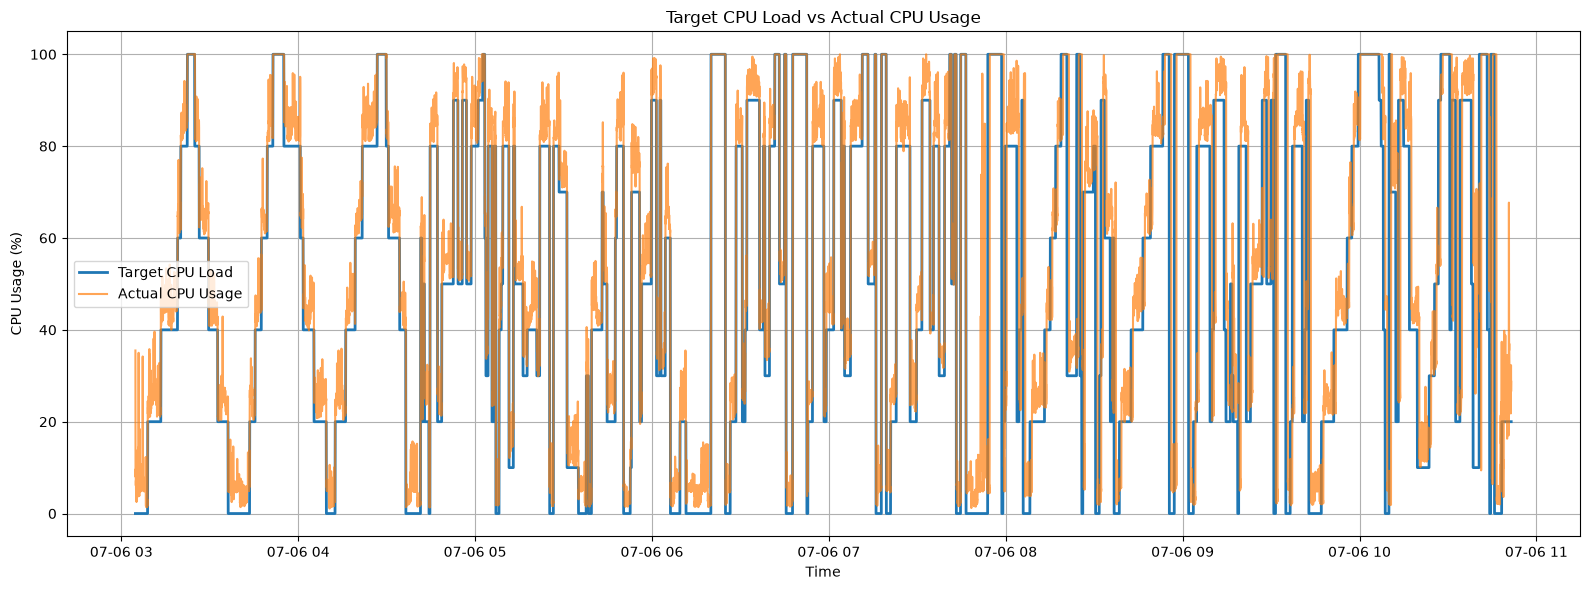

In [88]:
valid_target = merged.dropna(
    subset=["targetLoad", "cpuUsage"]
).copy()

plt.figure(figsize=(16, 6))

plt.plot(
    valid_target["timestamp"],
    valid_target["targetLoad"],
    label="Target CPU Load",
    linewidth=2
)

plt.plot(
    valid_target["timestamp"],
    valid_target["cpuUsage"],
    label="Actual CPU Usage",
    alpha=0.7
)

plt.title("Target CPU Load vs Actual CPU Usage")
plt.xlabel("Time")
plt.ylabel("CPU Usage (%)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [89]:
valid_target["loadError"] = (
    valid_target["cpuUsage"] -
    valid_target["targetLoad"]
)

print(
    "Mean Absolute Load Error:",
    valid_target["loadError"].abs().mean()
)

print(
    "Correlation:",
    valid_target[
        ["targetLoad", "cpuUsage"]
    ].corr().iloc[0, 1]
)

Mean Absolute Load Error: 9.706758030599666
Correlation: 0.8357873292805243


In [90]:
load_summary = (
    valid_target
    .groupby("targetLoad")
    .agg(
        samples=("cpuUsage", "count"),
        meanActualCPU=("cpuUsage", "mean"),
        stdActualCPU=("cpuUsage", "std"),
        meanTemperature=("cpuTemperature", "mean")
    )
    .reset_index()
)

display(load_summary)

,targetLoad,samples,meanActualCPU,stdActualCPU,meanTemperature
0,0.0,2283,14.174945,25.903071,73.725624
1,10.0,353,23.510765,17.527913,83.489802
2,20.0,1936,28.816994,17.493129,86.706663
3,30.0,557,38.335009,18.721840,91.413465
4,40.0,1575,45.894413,13.307687,94.103238
5,50.0,831,54.393381,11.426011,94.941576
6,60.0,735,62.869932,9.770566,95.134014
7,70.0,338,69.749112,19.232711,93.566568
8,80.0,2406,81.819659,12.556199,94.816313
9,90.0,983,83.514344,21.607254,94.476094


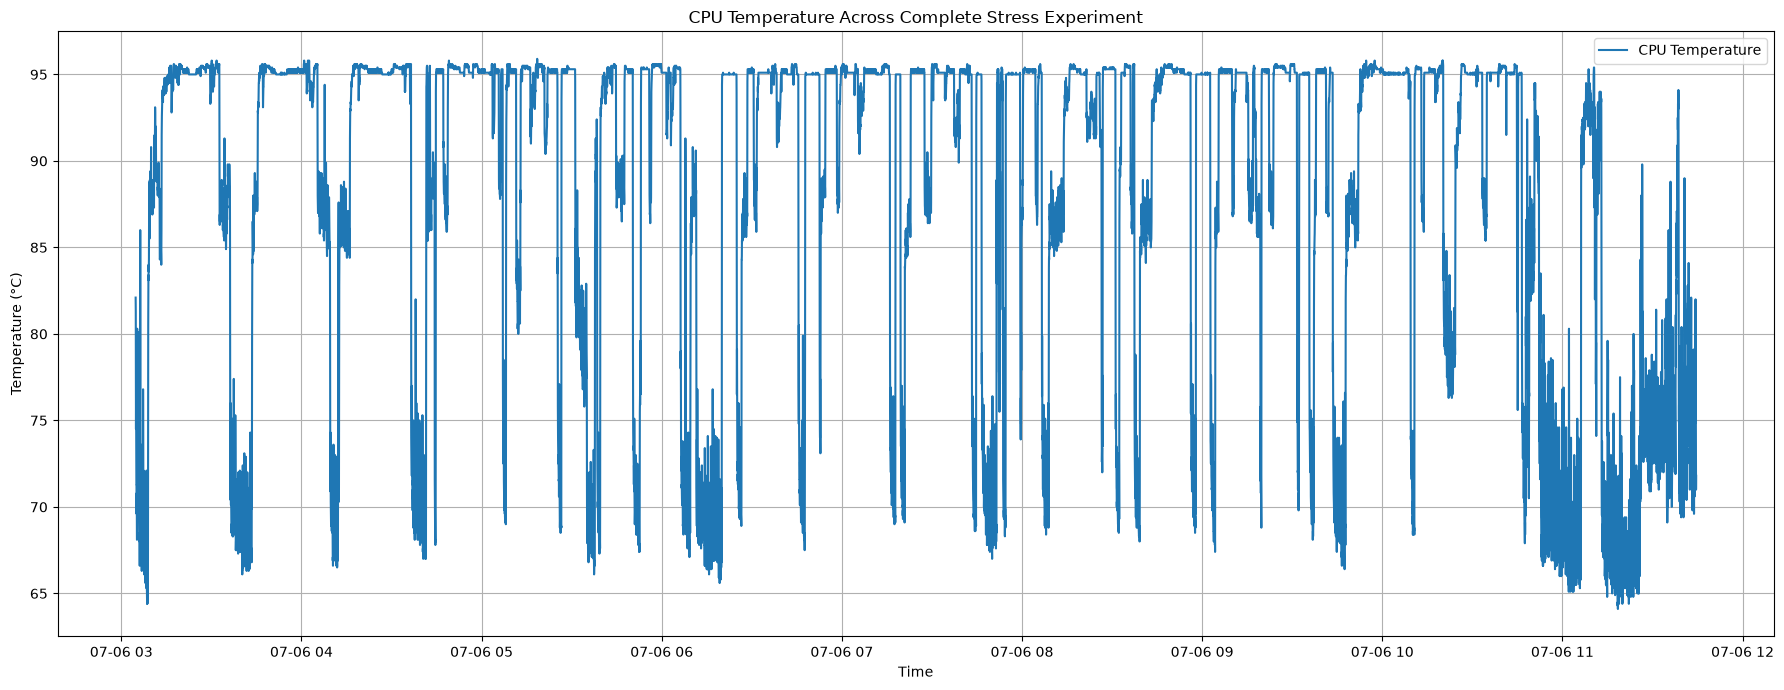

In [91]:
plt.figure(figsize=(18, 7))

plt.plot(
    merged["timestamp"],
    merged["cpuTemperature"],
    label="CPU Temperature"
)

plt.title(
    "CPU Temperature Across Complete Stress Experiment"
)

plt.xlabel("Time")
plt.ylabel("Temperature (°C)")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [92]:
mode_changes = merged[
    merged["mode"] != merged["mode"].shift()
][
    ["timestamp", "mode"]
]

display(mode_changes)

,timestamp,mode
0,2026-07-06 03:04:46.081798+05:30,INITIAL_IDLE
51,2026-07-06 03:06:30.090646700+05:30,RAMP
2715,2026-07-06 04:36:29.041038500+05:30,COOLING_AFTER_RAMP
2864,2026-07-06 04:41:30.039431700+05:30,CHAOS
5533,2026-07-06 06:11:30.880871100+05:30,COOLING_AFTER_CHAOS
5681,2026-07-06 06:16:29.824992+05:30,TRANSITION
8337,2026-07-06 07:46:30.363097600+05:30,COOLING_AFTER_TRANSITION
8485,2026-07-06 07:51:29.300892200+05:30,MIXED
13791,2026-07-06 10:51:29.435843+05:30,UNASSIGNED


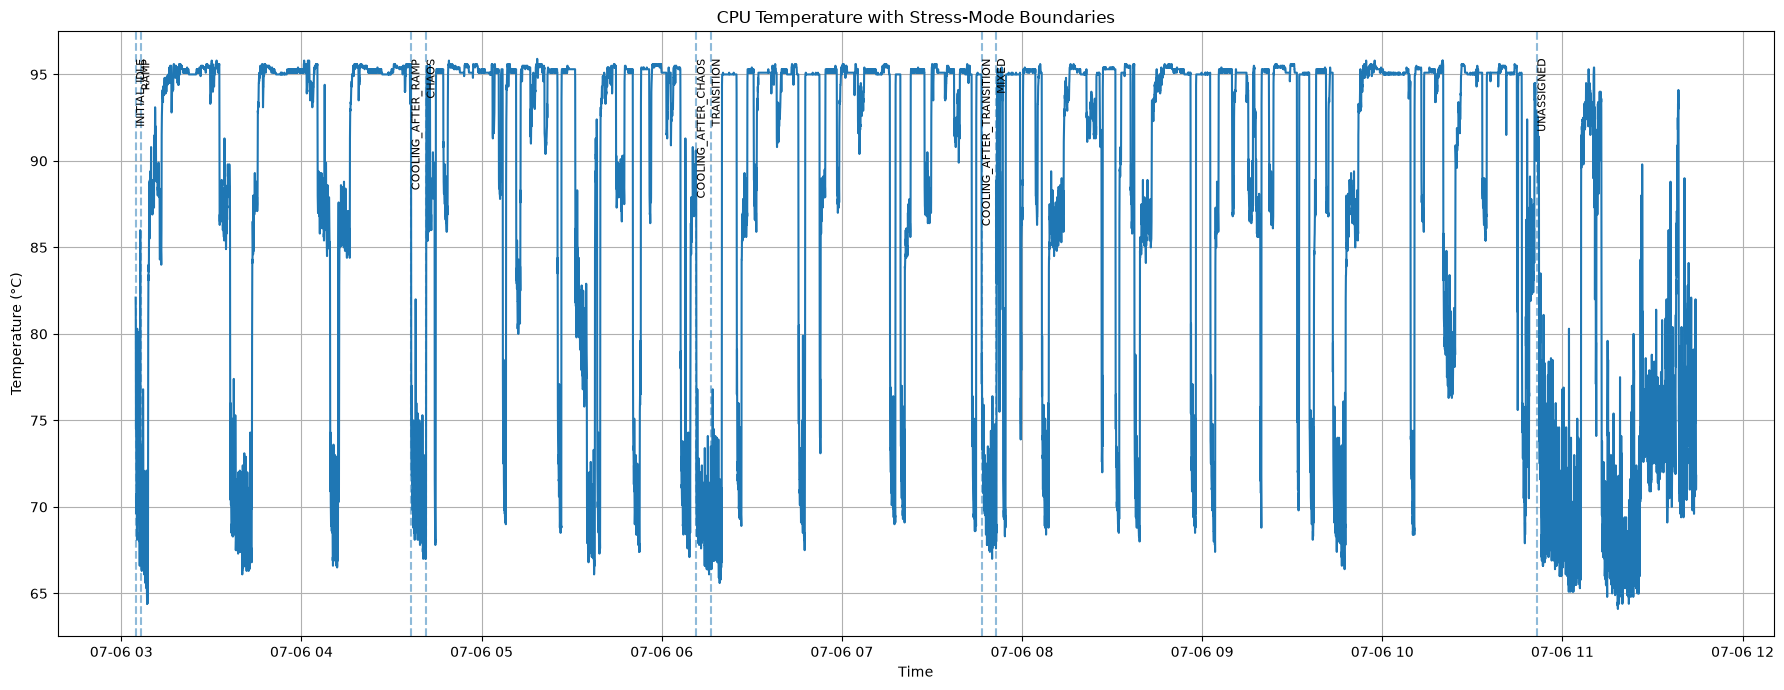

In [93]:
plt.figure(figsize=(18, 7))

plt.plot(
    merged["timestamp"],
    merged["cpuTemperature"],
    label="CPU Temperature"
)

for _, row in mode_changes.iterrows():

    plt.axvline(
        row["timestamp"],
        linestyle="--",
        alpha=0.5
    )

    plt.text(
        row["timestamp"],
        merged["cpuTemperature"].max(),
        str(row["mode"]),
        rotation=90,
        verticalalignment="top",
        fontsize=8
    )

plt.title(
    "CPU Temperature with Stress-Mode Boundaries"
)

plt.xlabel("Time")
plt.ylabel("Temperature (°C)")

plt.grid(True)
plt.tight_layout()
plt.show()

In [94]:
analysis_cols = [
    "cpuUsage",
    "cpuPackagePower",
    "cpuAverageClock",
    "cpuTemperature"
]

correlation = (
    merged[analysis_cols]
    .corr()
)

display(correlation)

,cpuUsage,cpuPackagePower,cpuAverageClock,cpuTemperature
cpuUsage,1.000000,0.882331,-0.129227,0.817578
cpuPackagePower,0.882331,1.000000,-0.060593,0.966493
cpuAverageClock,-0.129227,-0.060593,1.000000,-0.072976
cpuTemperature,0.817578,0.966493,-0.072976,1.000000


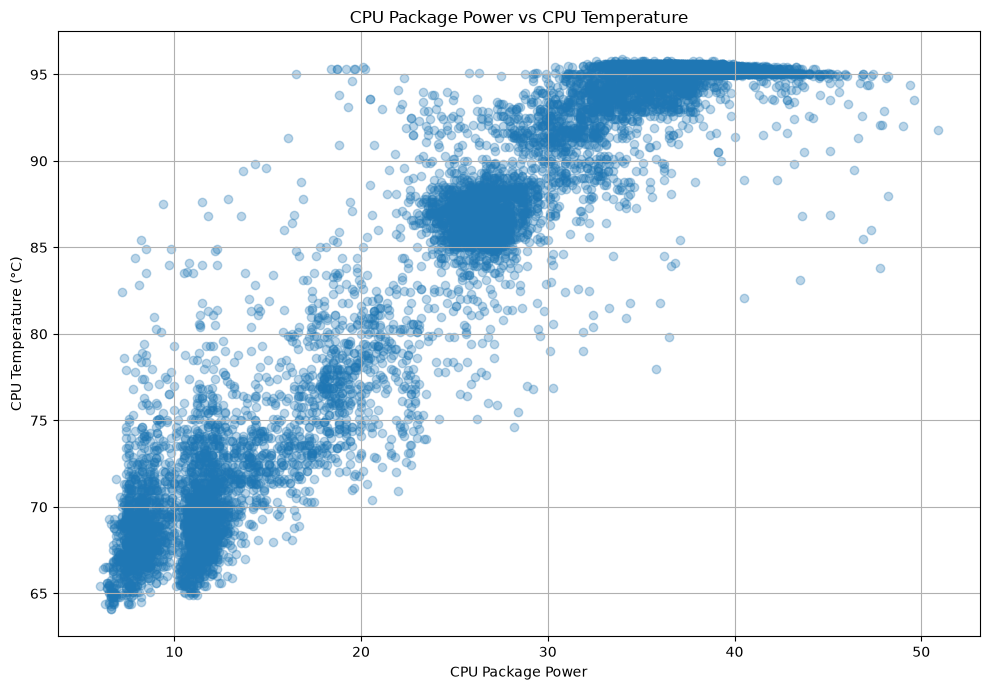

In [95]:
plt.figure(figsize=(10, 7))

plt.scatter(
    merged["cpuPackagePower"],
    merged["cpuTemperature"],
    alpha=0.3
)

plt.title("CPU Package Power vs CPU Temperature")
plt.xlabel("CPU Package Power")
plt.ylabel("CPU Temperature (°C)")
plt.grid(True)
plt.tight_layout()
plt.show()

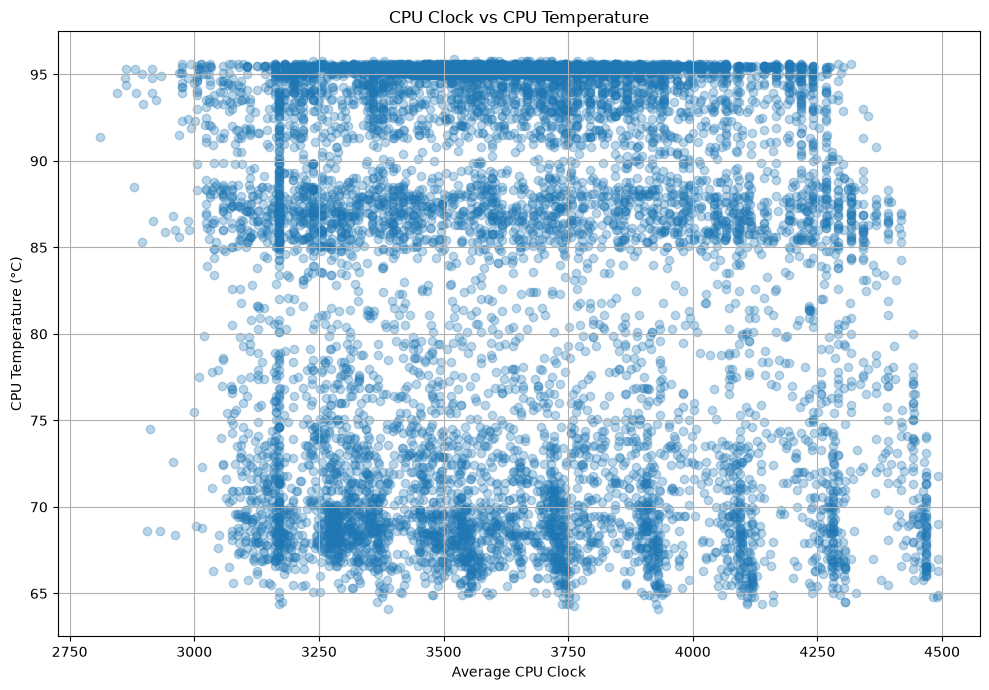

In [96]:
plt.figure(figsize=(10, 7))

plt.scatter(
    merged["cpuAverageClock"],
    merged["cpuTemperature"],
    alpha=0.3
)

plt.title("CPU Clock vs CPU Temperature")
plt.xlabel("Average CPU Clock")
plt.ylabel("CPU Temperature (°C)")
plt.grid(True)
plt.tight_layout()
plt.show()

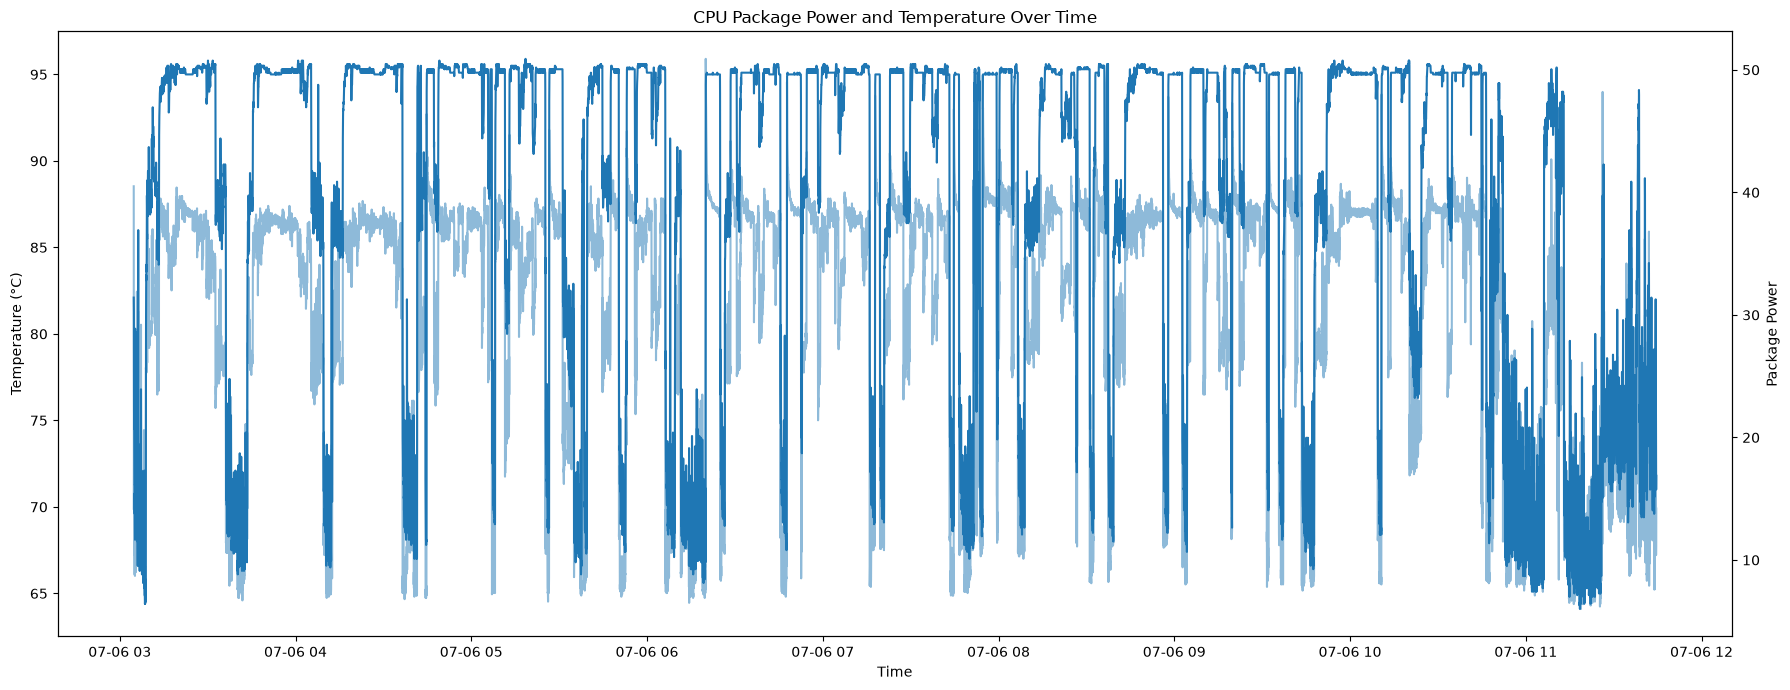

In [97]:
fig, ax1 = plt.subplots(figsize=(18, 7))

ax1.plot(
    merged["timestamp"],
    merged["cpuTemperature"],
    label="Temperature"
)

ax1.set_xlabel("Time")
ax1.set_ylabel("Temperature (°C)")

ax2 = ax1.twinx()

ax2.plot(
    merged["timestamp"],
    merged["cpuPackagePower"],
    alpha=0.5,
    label="Package Power"
)

ax2.set_ylabel("Package Power")

plt.title(
    "CPU Package Power and Temperature Over Time"
)

fig.tight_layout()
plt.show()

In [98]:
cooling = merged[
    merged["mode"]
    .astype(str)
    .str.contains("COOLING", case=False, na=False)
].copy()

print("Cooling samples:", len(cooling))

print(
    cooling["mode"].value_counts()
)

Cooling samples: 445
mode
COOLING_AFTER_RAMP          149
COOLING_AFTER_CHAOS         148
COOLING_AFTER_TRANSITION    148
Name: count, dtype: int64


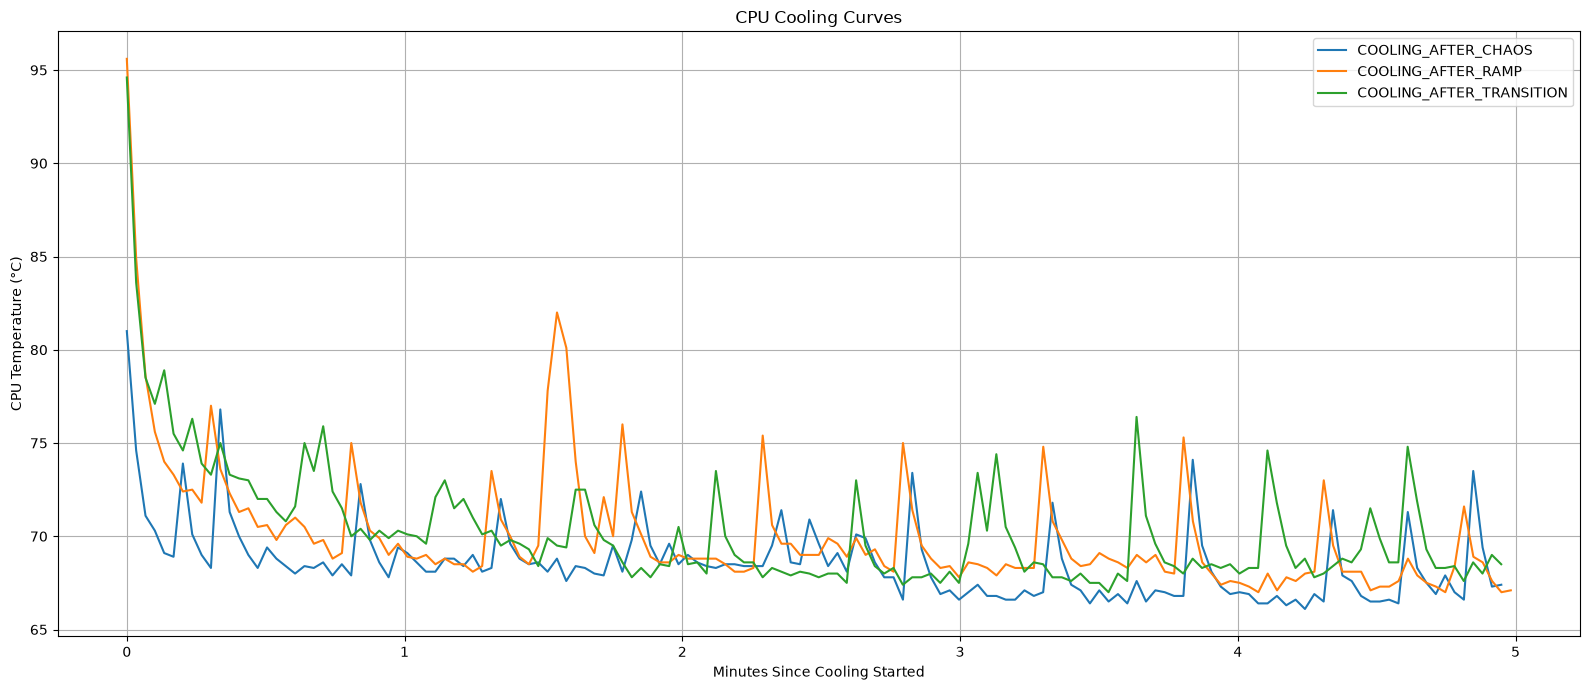

In [99]:
plt.figure(figsize=(16, 7))

for mode, group in cooling.groupby("mode"):

    group = group.sort_values("timestamp").copy()

    elapsed_minutes = (
        group["timestamp"] -
        group["timestamp"].min()
    ).dt.total_seconds() / 60

    plt.plot(
        elapsed_minutes,
        group["cpuTemperature"],
        label=mode
    )

plt.title("CPU Cooling Curves")
plt.xlabel("Minutes Since Cooling Started")
plt.ylabel("CPU Temperature (°C)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [100]:
cooling_summary = []

for mode, group in cooling.groupby("mode"):

    group = group.sort_values("timestamp")

    start_temp = group["cpuTemperature"].iloc[0]
    end_temp = group["cpuTemperature"].iloc[-1]

    duration_minutes = (
        group["timestamp"].iloc[-1] -
        group["timestamp"].iloc[0]
    ).total_seconds() / 60

    temperature_drop = (
        start_temp - end_temp
    )

    cooling_rate = (
        temperature_drop / duration_minutes
        if duration_minutes > 0
        else np.nan
    )

    cooling_summary.append({
        "mode": mode,
        "startTemperature": start_temp,
        "endTemperature": end_temp,
        "temperatureDrop": temperature_drop,
        "durationMinutes": duration_minutes,
        "coolingRatePerMinute": cooling_rate
    })

cooling_summary = pd.DataFrame(
    cooling_summary
)

display(cooling_summary)

,mode,startTemperature,endTemperature,temperatureDrop,durationMinutes,coolingRatePerMinute
0,COOLING_AFTER_CHAOS,81.0,67.4,13.6,4.948737,2.748176
1,COOLING_AFTER_RAMP,95.6,67.1,28.5,4.982975,5.719474
2,COOLING_AFTER_TRANSITION,94.6,68.5,26.1,4.948409,5.274423
